# <center>Resultados <center>

Neste Notebook estão disponíveis todos os códigos que utilizamos para gerar as imagens de exemplo. A estrutura do código é simples, e é importante que seja executado na ordem:

1. **Importação de pacotes:** aqui estão os principais pacotes e configurações deste notebook.
2. **Códigos que plotam espaços de fase 2D**
3. **Código para o espaço de fase do sistema $\dot{x} = \sin{x}$**
4. **Códigos para plotar diagramas de fase**

## **1.** Importação de pacotes

In [1]:
#=============================================================================================
#   Criado por Jimi (Willian Bonner) em 16/02/2026
#	Última atualização: 19/02/2026
#   Arquivo final do TCC
#   Versão 1.0
#   Último teste: 13/03/2026
#=============================================================================================

# 1. Pacotes importados

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import warnings
import sympy as sy
from gravipy.tensorial import *
import math
from IPython.display import display, Math, Latex
warnings.filterwarnings('ignore')

# Configuração do LaTeX
plt.rcParams.update({"text.usetex": True,"font.family": "serif","font.serif": ["Times"],
                     "text.latex.preamble": r"""\usepackage{amsmath}\usepackage{amssymb}
                     \usepackage{physics}
                     \usepackage{times}"""})

print('='*80)
display(Math(r'\LaTeX\ está\ ativo!'))
print('='*80)

<IPython.core.display.Math object>

## **2.** Código para plotar espaços de fase 2D

Estes códigos geram espaços de fase para sistemas bidimensionais da forma:

$$\begin{array}{l}
    \dot{x} = f(x,y)\\
    \dot{y} = g(x,y)
\end{array}
$$

Utilizamos o segundo código no TCC.

### **2.1** Código para o sistema:

$$\begin{array}{l}
    \dot{x} = x(1 - x^2) + \mu x \cos{y}\\
    \dot{y} = 1
\end{array}$$

Onde utilizamos os parâmetros $\mu = 1$.

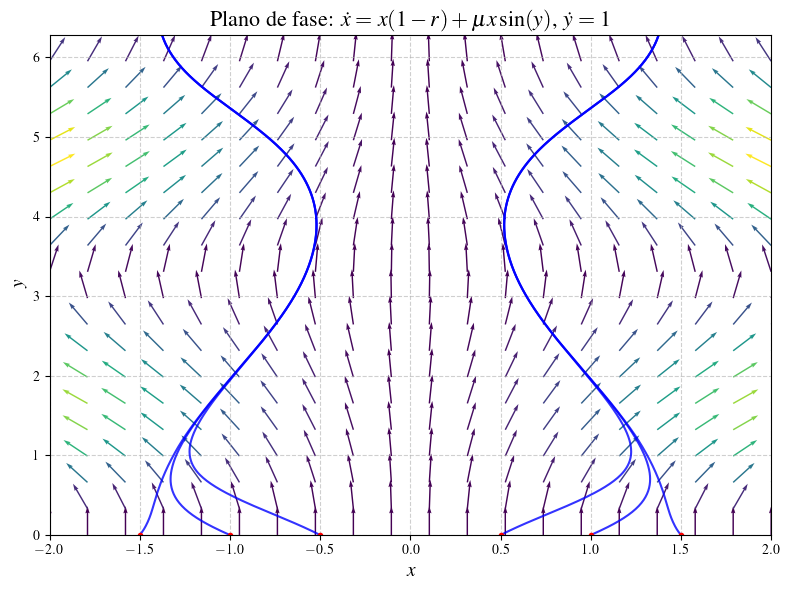

In [2]:
#=============================================================================================
#   Criado por Jimi (Willian Bonner) em 16/02/2026
#	Última atualização: 19/02/2026
#   Arquivo final do TCC
#   Versão 1.0
#=============================================================================================

# Parâmetros do sistema (ajuste conforme necessário)
mu = 1      # intensidade da perturbação
r_param = 1.0 # parâmetro r (constante)

# Definição do sistema de EDOs
# Supomos que x e y são as variáveis de estado, com y evoluindo linearmente.
# A equação é: dx/dt = x*(1 - r) + mu * x * sin(y), dy/dt = 1.
# Nota: r é tratado como um parâmetro constante. Para r = 1, o termo linear desaparece,
# resultando em órbitas periódicas fechadas (devido à periodicidade de sin(y)).
def sistema(t, z):
    x, y = z
    dx = x * (1 - x*x) + mu * x * np.cos(y)
    dy = 1.0
    return [dx, dy]

# Configuração do domínio
y_min, y_max = 0, 2*np.pi  # um período em y
x_min, x_max = -2.0, 2.0   # faixa para x (pode ser ajustada)

# Grade para o campo de direções
n_pontos = 20
x_vals = np.linspace(x_min, x_max, n_pontos)
y_vals = np.linspace(y_min, y_max, n_pontos)
X, Y = np.meshgrid(x_vals, y_vals)

# Calcula as componentes do campo vetorial na grade
U = X * (1 - r_param) + mu * X * np.sin(Y)
V = np.ones_like(X)  # dy/dt = 1 constante

# Normaliza os vetores para melhor visualização (opcional)
norm = np.sqrt(U**2 + V**2)
U_norm = U / norm
V_norm = V / norm

# Cria a figura
plt.figure(figsize=(8, 6))

# Desenha o campo de direções com setas (quiver)
# Usamos o campo normalizado para evitar setas muito longas/curtas
plt.quiver(X, Y, U_norm, V_norm, norm, cmap='viridis', scale=25, width=0.002)

# Integra e desenha algumas trajetórias
condicoes_iniciais = [-1.5, -1.0, -0.5, 0.5, 1.0, 1.5]  # valores de x0 com y0 = 0
t_max = 2 * np.pi  # tempo para percorrer um período completo em y
t_eval = np.linspace(0, t_max, 500)

for x0 in condicoes_iniciais:
    sol = solve_ivp(sistema, [0, t_max], [x0, 0], t_eval=t_eval, method='RK45')
    if sol.success:
        plt.plot(sol.y[0], sol.y[1], 'b-', linewidth=1.5, alpha=0.8)
        # Marca o ponto inicial
        plt.plot(sol.y[0][0], sol.y[1][0], 'ro', markersize=3)

# Configurações do gráfico
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$y$', fontsize=14)
plt.title(r'Plano de fase: $\dot{x}=x(1-r)+\mu x\sin(y)$, $\dot{y}=1$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustes para usar LaTeX (conforme configuração fornecida)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{physics}
        \usepackage{times}
    """
})

# Exibe o gráfico
plt.tight_layout()
plt.show()

### **2.2** Código para o sistema

$$\begin{array}{l}
    \dot{r} = r(1 - r^2) + \mu r \cos(\theta)\\
    \dot{\theta} = 1
\end{array}$$

Onde utilizamos os parâmetros $\mu = 0.4$.

1. O cálculo do campo vetorial no ítem *5.* é feito convertendo o sistema original de coordenadas polares para coordenadas cartesianas a partir das equações deduzidas:
$$\begin{array}{l}
    \dot{x} = (1 - r^2) x + \dfrac{\mu x^2}{r - y}\\[.4cm]
    \dot{y} = (1 - r^2) y + \dfrac{\mu x y}{r + x}
\end{array}$$ Onde $r = \sqrt(x^2+y^2)$. Evitamos r=0 para não causar problemas no código.

2. Filtramos pontos com $R$ muito pequeno para evitar setas estranhas no item *6.1*.

GERANDO O ESPAÇO DE FASES 2D...
ESPAÇO DE FASE GERADO COM SUCESSO! Imagem salva como "adex.PDF"


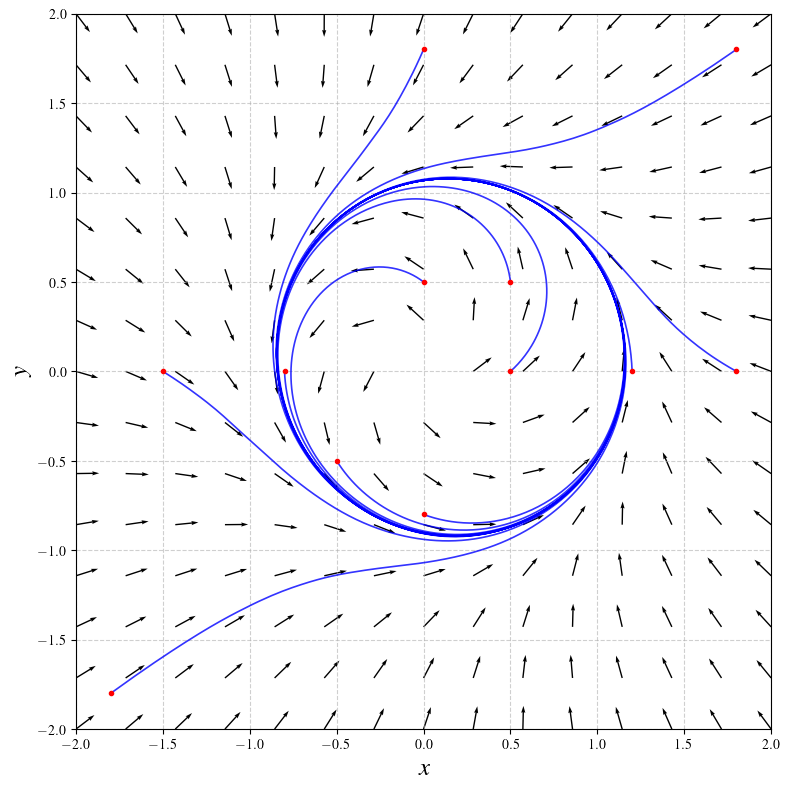

In [3]:
#=============================================================================================
#   Criado por Jimi (Willian Bonner) em 16/02/2026
#	Última atualização: 19/02/2026
#   Arquivo final do TCC
#   Versão 1.0
#=============================================================================================

print('='*80)
print('GERANDO O ESPAÇO DE FASES 2D...')

# 1. Parâmetro do sistema

mu = 0.4  # intensidade do acoplamento

# 2. Definição do sistema em coordenadas polares

def sistema_polar(t, estado):
    r, theta = estado
    dr = r * (1 - r**2) + mu * r * np.cos(theta)
    dtheta = 1.0
    return [dr, dtheta]

# 3. Função para converter coordenadas polares para cartesianas

def polar_para_cartesiano(estado_polar):
    r, theta = estado_polar
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

# 4. Configuração do domínio para o plano cartesiano

x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0

# 5. Grade para o campo de direções (opcional, usando as equações cartesianas)

n_pontos = 15
x_vals = np.linspace(x_min, x_max, n_pontos)
y_vals = np.linspace(y_min, y_max, n_pontos)
X, Y = np.meshgrid(x_vals, y_vals)
R = np.sqrt(X**2 + Y**2)

# 5.1 Para evitar divisão por zero, mascaramos pontos onde R é muito pequeno

epsilon = 1e-6
R_safe = np.maximum(R, epsilon)

U = (1 - R**2) * X + mu * X**2 / R_safe - Y
V = (1 - R**2) * Y + mu * X * Y / R_safe + X

# 5.2 Normalização para visualização

norm = np.sqrt(U**2 + V**2)
U_norm = U / norm
V_norm = V / norm

# 6. Cria a figura
plt.figure(figsize=(8, 8))

# 6.1 Campo de direções (apenas onde a magnitude não é muito pequena)

mask = R > 0.1  # só mostra setas onde r > 0.1

#plt.quiver(X[mask], Y[mask], U_norm[mask], V_norm[mask], norm[mask], cmap='viridis', scale=30, width=0.002, alpha=0.7)
plt.quiver(X[mask], Y[mask], U_norm[mask], V_norm[mask], color='black', scale=30, width=0.002)

# 7. Integração numérica para traçar órbitas a partir de várias condições iniciais

condicoes_iniciais_cart = [
    (0.5, 0), (1.2, 0), (1.8, 0), (-0.8, 0), (-1.5, 0), (1.8,1.8),
    (0, 0.5), (0, 1.8), (0, -0.8), (0.5, 0.5), (-0.5, -0.5), (-1.8,-1.8)
]

t_max = 4 * np.pi  # tempo para duas voltas completas em theta
t_eval = np.linspace(0, t_max, 1000)

for x0, y0 in condicoes_iniciais_cart:
    # 7.1 Converte para coordenadas polares
    r0 = np.sqrt(x0**2 + y0**2)
    theta0 = np.arctan2(y0, x0)
    if r0 < 1e-6:
        continue  # evita r=0
    # 7.2 Integra o sistema polar
    sol = solve_ivp(sistema_polar, [0, t_max], [r0, theta0], t_eval=t_eval, method='RK45')
    if sol.success:
        # Converte a trajetória para cartesianas
        r_traj = sol.y[0]
        theta_traj = sol.y[1]
        x_traj = r_traj * np.cos(theta_traj)
        y_traj = r_traj * np.sin(theta_traj)
        plt.plot(x_traj, y_traj, 'b-', linewidth=1.2, alpha=0.8)
        # Marca o ponto inicial
        plt.plot(x0, y0, 'ro', markersize=3)

# 8. Configurações do gráfico

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel(r'$x$', fontsize=18)
plt.ylabel(r'$y$', fontsize=18)
#plt.title(r'Plano de fase: $\dot{r}=r(1-r^{2})+\mu r\cos\theta$, $\dot{\theta}=1$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
#plt.axis('equal')  # para manter proporção
plt.tight_layout()

# 9. Configuração de salvamento da figura

print('ESPAÇO DE FASE GERADO COM SUCESSO! Imagem salva como "adex.PDF"')
print('='*80)
plt.savefig("adex1.pdf",dpi=300, transparent=True,bbox_inches='tight')


## **3.** Código para espaço de fase unidimensional

Este código gera grafico para o espaço de fases do tipo $$\dot{x} = \sin(x)$$ Observações sobre o código:

1. No item *3.* classificamos os pontos fixos como atratores e repulsores com números pares e ímpares, respectivamente.

GERANDO O ESPAÇO DE FASES 2D...
ESPAÇO DE FASE GERADO COM SUCESSO! Imagem salva como "adex2.PDF"


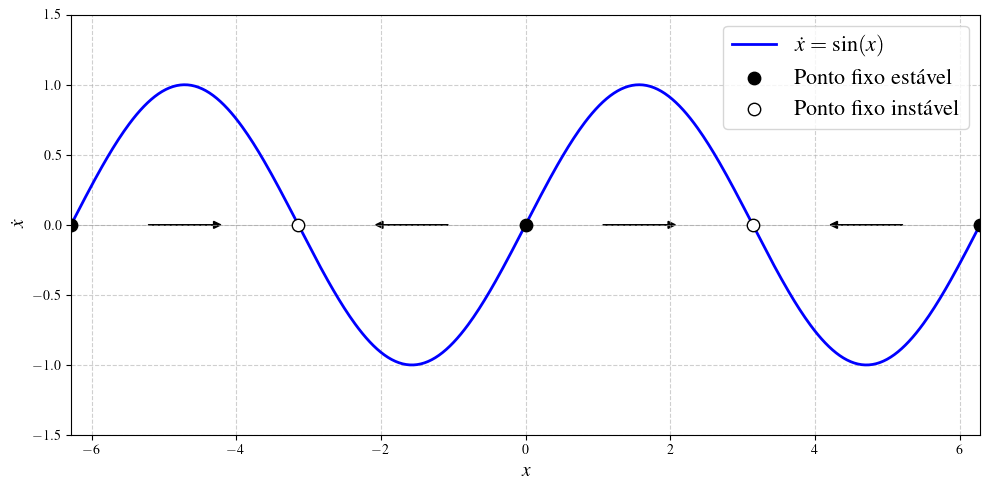

In [4]:
#=============================================================================================
#   Criado por Jimi (Willian Bonner) em 16/02/2026
#	Última atualização: 19/02/2026
#   Arquivo final do TCC
#   Versão 1.0
#=============================================================================================

print('='*80)
print('GERANDO O ESPAÇO DE FASES 2D...')

# 1. Domínio para a função

x = np.linspace(-2*np.pi, 2*np.pi, 500)
f = np.sin(x)

# 2. Pontos fixos

n_values = np.arange(-2, 3)  # -2, -1, 0, 1, 2
todos_pontos = n_values * np.pi

# 3. Classificação dos pontos fixos

pares = []   # múltiplos pares: 2nπ
impares = [] # múltiplos ímpares: (2n+1)π
for x0 in todos_pontos:
    # Verificar se x0/π é par
    if int(round(x0/np.pi)) % 2 == 0:
        pares.append(x0)
    else:
        impares.append(x0)

# 3. Cria a figura

plt.figure(figsize=(10, 5))

# 3.1 Plota o sistema

plt.plot(x, f, 'b-', linewidth=2, label=r'$\dot{x} = \sin(x)$')

# 3.2 Adiciona setas no eixo x (em y=0) indicando a direção do fluxo

comprimento_seta = 1.0   # comprimento de cada seta

# 3.3 Intervalos entre pontos fixos

for i in range(len(todos_pontos)-1):
    a = todos_pontos[i]
    b = todos_pontos[i+1]
    x_medio = (a + b) / 2   # ponto médio do intervalo
    if np.sin(x_medio) > 0:
        # Fluxo para a direita: seta apontando para +x
        plt.arrow(x_medio - comprimento_seta/2, 0,
                  comprimento_seta, 0,
                  head_width=0.05, head_length=0.1,
                  fc='black', ec='black', 
                  length_includes_head=True)
    else:
        # Fluxo para a esquerda: seta apontando para -x
        plt.arrow(x_medio + comprimento_seta/2, 0,
                  -comprimento_seta, 0,
                  head_width=0.05, head_length=0.1,
                  fc='black', ec='black', 
                  length_includes_head=True)

# Plota os pontos fixos com a distinção:  Pares (2nπ) = bolinha preta preenchida; Ímpares ((2n+1)π) = bolinha branca com borda preta

plt.scatter(pares, np.zeros_like(pares), color='black', s=80, zorder=5, label=r'Ponto fixo estável')
plt.scatter(impares, np.zeros_like(impares), facecolors='white', edgecolors='black', s=80, zorder=5, label=r'Ponto fixo instável')

# 4. Configurações do gráfico

plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)  # eixo x
plt.xlim(-2*np.pi, 2*np.pi)
plt.ylim(-1.5, 1.5)  # ajustado para dar espaço
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$\dot{x}$', fontsize=14)
#plt.title(r'Espaço de fases de $\dot{x} = \sin(x)$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()

# 5. Configura e salva o gráfico

print('ESPAÇO DE FASE GERADO COM SUCESSO! Imagem salva como "adex2.PDF"')
print('='*80)
plt.savefig("adex2.pdf",dpi=300, transparent=True,bbox_inches='tight')

## **4.** Código para plotar diagramas de fase

Os códigos a seguir plotam espaços de fase para as bifurcações:

1. Bifurcação transcrítica;
2. Bifurcação pitchfork subcrítica.

### **4.1** Bifurcação transcrítica

A bifurcação transcrítica possui a seguinte forma normal:$$\dot{x} = x(r - x).$$

Observações sobre o código:

1. No item *2.*, o código plota as curvas com diferenciação de estabilidade: Se $r < 0$, então $x = 0$ é estável (linha sólida) e $x = r$ é instável (tracejada). Se $r > 0$, então $x = 0$ é instável (tracejada) e $x = r$ é estável (sólida).

GERANDO O DIAGRAMA DE BIFURCAÇÃO...
DIAGRAMA DE BIFURCAÇÃO CONCLUÍDO COM SUCESSO! Figura salva como dbf02.PDF


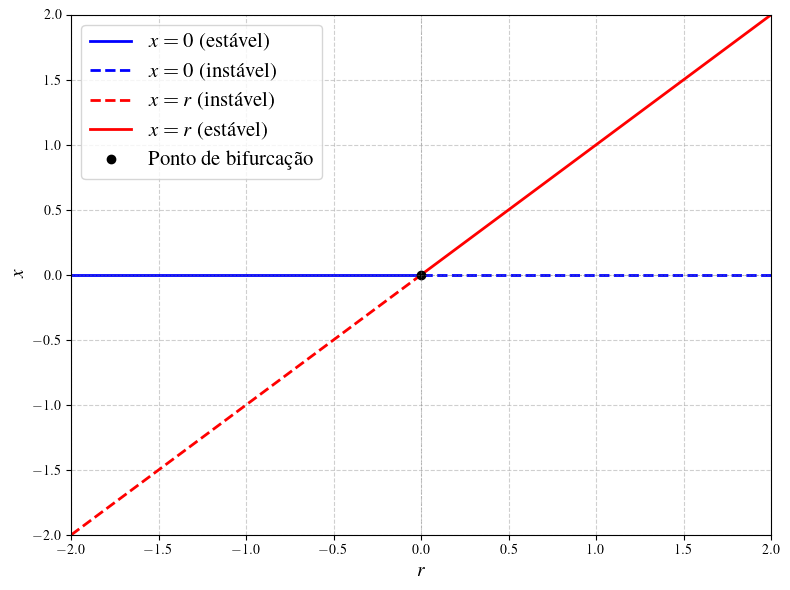

In [5]:
#=============================================================================================
#   Criado por Jimi (Willian Bonner) em 16/02/2026
#	Última atualização: 19/02/2026
#   Arquivo final do TCC
#   Versão 1.0
#=============================================================================================

print('='*80)
print('GERANDO O DIAGRAMA DE BIFURCAÇÃO...')

# 1. Parâmetros para o diagrama

r = np.linspace(-2, 2, 400)          # intervalo do parâmetro de bifurcação
x1 = np.zeros_like(r)                 # ponto fixo x = 0
x2 = r                                 # ponto fixo x = r

# 2. Cria a figura

plt.figure(figsize=(8, 6))

# 2. Plota as curvas de estabilidade/instabilidade: 

mask_neg = r < 0
mask_pos = r > 0
mask_zero = r == 0  # ponto de bifurcação (pode ser marcado separadamente)

# 2.1 Ramo x=0

plt.plot(r[mask_neg], x1[mask_neg], 'b-', linewidth=2, label=r'$x=0$ (estável)')
plt.plot(r[mask_pos], x1[mask_pos], 'b--', linewidth=2, label=r'$x=0$ (instável)')

# 2.2 Ramo x=r

plt.plot(r[mask_neg], x2[mask_neg], 'r--', linewidth=2, label=r'$x=r$ (instável)')
plt.plot(r[mask_pos], x2[mask_pos], 'r-', linewidth=2, label=r'$x=r$ (estável)')

# 2.3 Marca o ponto de bifurcação (r=0, x=0)

plt.plot(0, 0, 'ko', markersize=6, label='Ponto de bifurcação')

# 3. Configurações do gráfico

plt.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel(r'$r$', fontsize=14)
plt.ylabel(r'$x$', fontsize=14)
#plt.title(r'Diagrama de bifurcação transcrítica: $\dot{x} = r x - x^2$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=15)

# 4. Comando para salvar a figura.

print('DIAGRAMA DE BIFURCAÇÃO CONCLUÍDO COM SUCESSO! Figura salva como dbf02.PDF')
print('='*80)
plt.tight_layout()
plt.savefig("dbf02.pdf",dpi=300, transparent=True,bbox_inches='tight')

### **4.2** Bifurcação pitchfork supercrítica

A bifurcação pitchfork supercrítica possui a seguinte forma normal:$$x(r - x^2).$$

GERANDO O DIAGRAMA DE BIFURCAÇÃO...
DIAGRAMA DE BIFURCAÇÃO GERADO COM SUCESSO! Imagem salva como "dbf03.PDF"


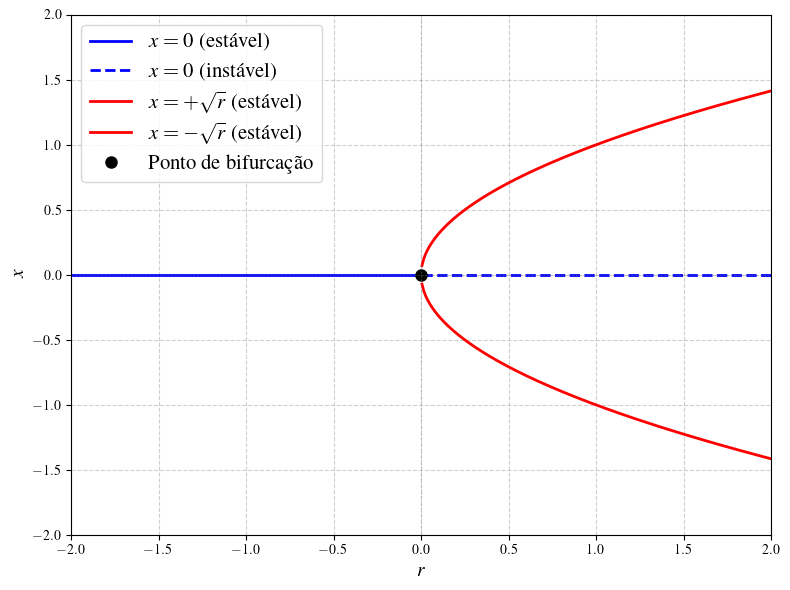

In [6]:
#=============================================================================================
#   Criado por Jimi (Willian Bonner) em 16/02/2026
#	Última atualização: 19/02/2026
#   Arquivo final do TCC
#   Versão 1.0
#=============================================================================================

print('='*80)
print('GERANDO O DIAGRAMA DE BIFURCAÇÃO...')

# 1. Parâmetros

r = np.linspace(-2, 2, 400)
r_pos = r[r >= 0]  # apenas para r >= 0

# 2. Pontos fixos

x0 = np.zeros_like(r)           # x = 0 para todo r
x_plus = np.sqrt(r_pos)         # ramo positivo para r >= 0
x_minus = -np.sqrt(r_pos)       # ramo negativo para r >= 0

# 3. Cria a figura
plt.figure(figsize=(8, 6))

# 4 Criação e configurações dos ramos:

# 4.1 Ramo x = 0: Estável para r < 0, instável para r > 0

mask_r_neg = r < 0
mask_r_pos = r > 0
plt.plot(r[mask_r_neg], x0[mask_r_neg], 'b-', linewidth=2, label=r'$x=0$ (estável)')
plt.plot(r[mask_r_pos], x0[mask_r_pos], 'b--', linewidth=2, label=r'$x=0$ (instável)')

# 4.2 Ramos simétricos (estáveis)

plt.plot(r_pos, x_plus, 'r-', linewidth=2, label=r'$x=+\sqrt{r}$ (estável)')
plt.plot(r_pos, x_minus, 'r-', linewidth=2, label=r'$x=-\sqrt{r}$ (estável)')

# 4.3 Marca o ponto de bifurcação

plt.plot(0, 0, 'ko', markersize=8, label='Ponto de bifurcação')

# 5. Configurações do gráfico

plt.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel(r'$r$', fontsize=14)
plt.ylabel(r'$x$', fontsize=14)
#plt.title(r'Diagrama de bifurcação pitchfork supercrítica: $\dot{x} = r x - x^3$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=15)
plt.tight_layout()

# 5. Configura e salva o gráfico

print('DIAGRAMA DE BIFURCAÇÃO GERADO COM SUCESSO! Imagem salva como "dbf03.PDF"')
print('='*80)
plt.savefig("dbf03.pdf",dpi=300, transparent=True,bbox_inches='tight')

## **5.** Verificação final

Antes de subir o código para o Github, fiz um teste de compilação utilizando o Jupyter Notebook do Anaconda Navigator em 13 de Março de 2026.

Está tudo funcionando corretamente.